In [ ]:
import pandas as pd
from pathlib import Path

# Find repo root
repo_root = Path.cwd()
for candidate in [repo_root] + list(repo_root.parents):
    if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
        repo_root = candidate
        break

print('Repo root:', repo_root)

# Read the berkhout file with semicolon separator
file_path = repo_root / 'input_stressors' / 'berkhout_249_v2.csv'
df = pd.read_csv(file_path, sep=';')

print(f'File loaded: {file_path.name}')
print(f'Shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())
print(f'\nColumn names:')
print(df.columns.tolist())
print(f'\nData types:')
print(df.dtypes)

Repo root: d:\Users\jvanruitenbeek\data_validation
File loaded: berkhout_249_v2.csv
Shape: (43104, 25)

First few rows:
   # STN  YYYYMMDD     HH    DD    FH    FF    FX      T   T10N     TD  ...  \
0    249  20210101  00:00   260    10    10    20     -5            -9  ...   
1    249  20210101  01:00   240    10    20    20     -5           -10  ...   
2    249  20210101  02:00   230    20    20    30      4            -4  ...   
3    249  20210101  03:00   230    30    30    30     12             2  ...   
4    249  20210101  04:00   320    20    20    50     12             4  ...   

      VV      N      U     WW    IX      M      R      S      O      Y  
0     34            97     10     7      0      0      0      0      0  
1     48            96     10     7      0      0      0      0      0  
2     29            94     10     7      0      0      0      0      0  
3     39            93     10     7      0      0      0      0      0  
4     49            94     51     7     

C:\Users\jvanruitenbeek\AppData\Local\Temp\21\ipykernel_35576\359564335.py:15: DtypeWarning: Columns (3,4,5,6,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';')


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43104 entries, 2021-01-01 00:00:00 to 2025-12-01 23:00:00
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   # STN         43104 non-null  int64  
 1   YYYYMMDD      43104 non-null  object 
 2   HH            43104 non-null  object 
 3   DD            43104 non-null  object 
 4   FH            43104 non-null  object 
 5   FF            43104 non-null  object 
 6   FX            43104 non-null  object 
 7   T             43104 non-null  int64  
 8   T10N          43104 non-null  object 
 9   TD            43104 non-null  int64  
 10  SQ            43104 non-null  int64  
 11  Q             43104 non-null  int64  
 12  DR            43104 non-null  int64  
 13  RH            43104 non-null  int64  
 14  P             43104 non-null  object 
 15  VV            43104 non-null  object 
 16  N             43104 non-null  object 
 17  U             43104 non-null  int6

# Calculating Makkink and converting to .csv for pastas

In [13]:
# 2. Kolomnamen opschonen
df.columns = [c.strip() for c in df.columns]

# 3. Timestamp maken (begin van het uur)
df['YYYYMMDD'] = df['YYYYMMDD'].astype(str).str.strip()
df['HH'] = df['HH'].astype(str).str.strip()

df['datetime_str'] = df['YYYYMMDD'] + ' ' + df['HH']
df['timestamp'] = pd.to_datetime(df['datetime_str'], format='%Y%m%d %H:%M')
df = df.set_index('timestamp').sort_index()

# 4. Regen in mm/uur
df['RH'] = pd.to_numeric(df['RH'], errors='coerce')
rain_df = df[['RH']].copy()
rain_df['rain_mm'] = rain_df['RH'].clip(lower=0) / 10.0   # 0.1 mm → mm
rain_df = rain_df[['rain_mm']]
rain_df.to_csv('knmi_berkhout_hourly_rain.csv')

# 5. Makkink verdamping in mm/uur
df['T'] = pd.to_numeric(df['T'], errors='coerce')
df['Q'] = pd.to_numeric(df['Q'], errors='coerce')

df['T_C'] = df['T'] / 10.0                      # 0.1°C → °C
df['Rs_MJ'] = df['Q'].clip(lower=0) * 0.01      # ✔ J/cm² → MJ/m²

T = df['T_C'].fillna(0)
gamma = 0.066
delta = 4098 * (0.6108 * np.exp((17.27 * T) / (T + 237.3))) / ((T + 237.3) ** 2)

df['makkink_mm'] = 0.65 * (delta / (delta + gamma)) * df['Rs_MJ']
evap_df = df[['makkink_mm']]
evap_df.to_csv('knmi_berkhout_hourly_makkink.csv')

# Penman Monteith

In [23]:
import numpy as np
import pandas as pd

# Ensure numeric types
df["T"] = pd.to_numeric(df["T"], errors="coerce")
df["TD"] = pd.to_numeric(df["TD"], errors="coerce")
df["FF"] = pd.to_numeric(df["FF"], errors="coerce")
df["Q"] = pd.to_numeric(df["Q"], errors="coerce")

# ---- Constants ----
z = 1  # station altitude Berkhout (m)
P = 101.3 * ((293 - 0.0065*z) / 293)**5.26  # atmospheric pressure (kPa)
gamma = 0.000665 * P                        # psychrometric constant

# ---- Required variables ----
df["T2"] = df["T"] / 10.0  # °C
df["Td"] = df["TD"] / 10.0 # dewpoint temp °C
df["u2"] = df["FF"] / 10.0 # wind m/s

# ---- Vapor pressure ----
df["es"] = 0.6108 * np.exp((17.27*df["T2"]) / (df["T2"] + 237.3))
df["ea"] = 0.6108 * np.exp((17.27*df["Td"]) / (df["Td"] + 237.3))
df["VPD"] = (df["es"] - df["ea"]).clip(lower=0)

# ---- Radiation conversion ----
df["Rs"] = df["Q"].clip(lower=0) * 0.01  # J/cm² → MJ/m²

# ---- Slope ----
df["delta"] = (4098 * df["es"]) / ((df["T2"] + 237.3)**2)

# ---- Net radiation = Rs (no soil heat on hourly scale) ----
Rn = df["Rs"]

# ---- FAO-56 Hourly PM ET ----
df["ET_PM"] = (
    0.408 * df["delta"] * Rn +
    gamma * (900/(df["T2"]+273)) * df["u2"] * df["VPD"]
) / (df["delta"] + gamma*(1 + 0.34*df["u2"]))

df["ET_PM"] = df["ET_PM"].clip(lower=0)

pm_df = df[["ET_PM"]]
pm_df.to_csv("knmi_berkhout_hourly_penman_monteith.csv")
print("Saved Penman-Monteith successfully!")

Saved Penman-Monteith successfully!


In [22]:
# Convert T
df["T2"] = df["T"] / 10.0   # °C

# Radiation as before
df["Rs"] = df["Q"].clip(lower=0) * 0.01  # MJ/m²

# Estimate ET0
df["ET_HS"] = 0.0023 * (df["T2"] + 17.8) * np.sqrt(df["Rs"]) * df["Rs"]
df["ET_HS"] = df["ET_HS"].clip(lower=0)

hs_df = df[["ET_HS"]]
hs_df.to_csv("knmi_berkhout_hourly_hargreaves.csv")
print("Saved Hargreaves ET to CSV!")

Saved Hargreaves ET to CSV!


# Data compare

<Figure size 1000x500 with 0 Axes>

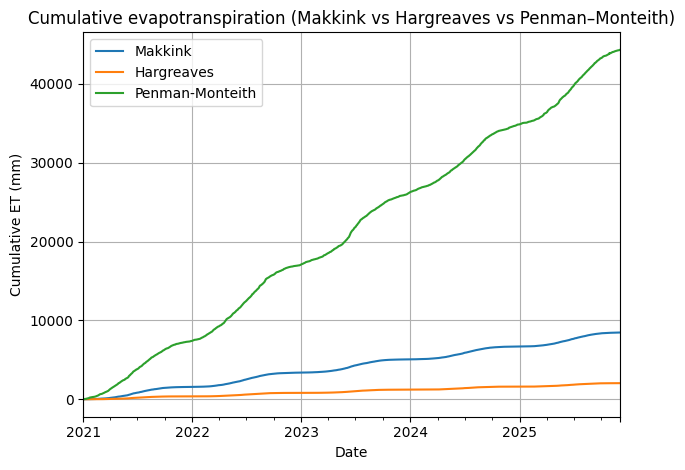

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load series
makkink = pd.read_csv("knmi_berkhout_hourly_makkink.csv", parse_dates=[0], index_col=0)
hargreaves = pd.read_csv("knmi_berkhout_hourly_hargreaves.csv", parse_dates=[0], index_col=0)
penman = pd.read_csv("knmi_berkhout_hourly_penman_monteith.csv", parse_dates=[0], index_col=0)

# Rename columns to common labels
makkink = makkink.rename(columns={"makkink_mm": "Makkink"})
hargreaves = hargreaves.rename(columns={"ET_HS": "Hargreaves"})
penman = penman.rename(columns={"ET_PM": "Penman-Monteith"})

# Combine into single DataFrame
et = pd.concat([makkink["Makkink"], hargreaves["Hargreaves"], penman["Penman-Monteith"]], axis=1)

# Optional: filter to a specific period
# et = et.loc["2024-01-01":"2024-12-31"]

# Cumulative sum (mm)
et_cum = et.cumsum()

# Plot
plt.figure(figsize=(10, 5))
et_cum.plot()
plt.ylabel("Cumulative ET (mm)")
plt.xlabel("Date")
plt.title("Cumulative evapotranspiration (Makkink vs Hargreaves vs Penman–Monteith)")
plt.grid(True)
plt.tight_layout()
plt.show()